In [19]:
import sys

sys.path.append("anomaly-detection/diffusion-anomaly")

from guided_diffusion.script_util import (
    model_and_diffusion_defaults,
    diffusion_defaults,
    create_model_and_diffusion,
    args_to_dict,
    add_dict_to_argparser,
    create_gaussian_diffusion
)

from guided_diffusion.resample import UniformSampler
from guided_diffusion import dist_util

from guided_diffusion.fp16_util import *

from guided_diffusion.respace import space_timesteps

import numpy as np
import matplotlib.pyplot as plt
import torch as th

import h5py

import os

import pickle
from guided_diffusion.train_util import visualize

Setting up a new session...
/home/munjung/.conda/envs/diffusion/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Setting up a new session...


In [2]:
def load_data(filename, threshold=0):
    with h5py.File(str(filename), "r") as f:
        # scale charge by value
        arrs = [f[ev]["raw"][:] for ev in f.keys()]
    allarrs = []
    for arr in arrs:
        nrows, ncols = (512, 512)
        plane_boundaries = [0, 1984, 3968, 5638]
        for planeno, (wlo, whi) in enumerate(zip(plane_boundaries[:-1], plane_boundaries[1:])):
            cscale = [200., 100., 200.][planeno]
            
            planearr = arr[wlo:whi, :]/cscale
            h, w = planearr.shape
            ll = planearr[:(h//nrows)*nrows, :(w//nrows)*nrows].reshape(h//nrows, nrows, -1, ncols).swapaxes(1,2).reshape(-1, nrows, ncols)

            if np.max(ll) < threshold:
                continue
            allarrs.append(ll)
            

    _cache_file = visualize(np.expand_dims(np.concatenate(allarrs), axis=1)).astype(np.float32)
    _cache_true = np.ones((_cache_file.shape[0], 1, nrows, ncols)).astype(np.float32)
    return _cache_file, _cache_true

In [3]:
def noise_frames(diffusion, model, imgs, T):
    # noised frames

    # DDIM
    ddim_noisef = diffusion.ddim_sample_loop_progressive(model, imgs.shape, time=T, noise=imgs, 
                                                reverse=True, progress=True)

    ddim_noise = list(ddim_noisef)

    ddim_noised = ddim_noise[-1]["sample"]

    # Random
    rand_noised = diffusion.q_sample(imgs, th.tensor(T, device=dist_util.dev()))

    return ddim_noised, rand_noised

In [4]:
def reconstruct_frames(diffusion, model, imgs, ddim_noised, rand_noised, T):
    # Reconstruct
    ddim_2_ddim = diffusion.ddim_sample_loop_progressive(model, 
                    imgs.shape, time=T, noise=ddim_noised, progress=True)

    rand_2_ddim = diffusion.ddim_sample_loop_progressive(model, 
                    imgs.shape, time=T, noise=rand_noised, progress=True)

    ddim_2_ddpm = diffusion.p_sample_loop_progressive(model, 
                    imgs.shape, time=T, noise=ddim_noised, progress=True)

    rand_2_ddpm = diffusion.p_sample_loop_progressive(model, 
                    imgs.shape, time=T, noise=rand_noised, progress=True)


    ddim_2_ddim_reco = list(ddim_2_ddim)[-1]["sample"]
    rand_2_ddim_reco = list(rand_2_ddim)[-1]["sample"]
    ddim_2_ddpm_reco = list(ddim_2_ddpm)[-1]["sample"]
    rand_2_ddpm_reco = list(rand_2_ddpm)[-1]["sample"]

    recos = [
        ddim_2_ddim_reco,
        rand_2_ddim_reco,
        ddim_2_ddpm_reco,
        rand_2_ddpm_reco
    ]

    return recos


In [5]:
th.set_grad_enabled(False)

args = model_and_diffusion_defaults()
diffusion_args = diffusion_defaults()

# MODEL
args["image_size"] = 512
args["num_channels"] = 32
args["class_cond"] = False
args["num_res_blocks"] = 2
args["num_heads"] = 8
args["learn_sigma"] = True
args["use_scale_shift_norm"] = False
args["attention_resolutions"] = "16,32"
args["channel_mult"] = "1,2,4,8,8,8"

# DIFFUSION
diffusion_args["diffusion_steps"] = 1000
diffusion_args["noise_schedule"] = "linear"
diffusion_args["rescale_learned_sigmas"] = False
diffusion_args["rescale_timesteps"] = False

diffusion_args.pop("diffusion_steps")
diffusion_args.pop("timestep_respacing")

# TODO: change?
diffusion_args["learn_sigma"] = True

args = args | diffusion_args

model, diffusion = create_model_and_diffusion(**args)

timestepresp1 
numberinchannels 1
steps 1000 [1000]
predict_xstart False
predict_xprev False
model_mean_type ModelMeanType.EPSILON
num_timesteps 1000
sectioncount [1000]
all steps {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185,

In [6]:
MODEL = "/exp/sbnd/data/users/gputnam/training-SBND/iterE/results/brats2update111000.pt"

model.load_state_dict(
    dist_util.load_state_dict(MODEL, map_location="cpu")
)

model.to(dist_util.dev())
_ = model.eval()

In [19]:
BATCH_SIZE = 3

In [31]:
save_data = {}

In [ ]:
input_base_dir = "/scratch/7DayLifetime/munjung/anomaly-detection-raw-h5/run_18515_sub_1_evt_29363"
subfiles = os.listdir(input_base_dir)
filenames = [f for f in subfiles if f.startswith("g4-raw-")]
for filename in filenames[:1]:
    print(f"Processing {filename}")
    _cache_file, _cache_true = load_data(input_base_dir + "/" + filename, threshold=1.0)

    # for i in range(0, len(_cache_file), BATCH_SIZE):
    for bidx, bstart in enumerate(range(0, 4, BATCH_SIZE)):
        print(f"Processing batch {bidx}")
        imgs = th.tensor(_cache_file[bstart:bstart+BATCH_SIZE], device=dist_util.dev())

        for iimg in range(len(imgs)):
            print(bstart + iimg)
            save_data[bstart + iimg] = {
                "original": imgs[iimg].cpu().numpy()
            }

        for T in range(100, 300, 100):
            print(f"Processing T={T}")
            ddim_noised, rand_noised = noise_frames(diffusion, model, imgs, T)
            recos = reconstruct_frames(diffusion, model, imgs, ddim_noised, rand_noised, T)

            for iimg in range(len(imgs)):
                iidx = bstart + iimg
                save_data[iidx]["ddim_noised-T%d"%T] = ddim_noised[iimg].cpu().numpy()
                save_data[iidx]["rand_noised-T%d"%T] = rand_noised[iimg].cpu().numpy()
                save_data[iidx]["ddim2ddim-T%d"%T] = recos[0][iimg].cpu().numpy()
                save_data[iidx]["rand2ddim-T%d"%T] = recos[1][iimg].cpu().numpy()
                save_data[iidx]["ddim2ddpm-T%d"%T] = recos[2][iimg].cpu().numpy()
                save_data[iidx]["rand2ddpm-T%d"%T] = recos[3][iimg].cpu().numpy()

Processing g4-raw-1.h5
Processing batch 0
0
1
2
Processing batch 1
3
4
5


In [40]:
titles = [
    "Shower Undershoot",
    "Bad Wire",
    "Dead Wires",
]

reco_names = [
    "DDIM to DDIM",
    "Random to DDIM",
    "DDIM to DDPM",
    "Random to DDPM",
]

In [43]:
save_dir = "."
with open(save_dir + "/"+filename.split(".")[0]+".pkl", "wb") as f:
    pickle.dump(save_data, f)

with open(save_dir + "/"+filename.split(".")[0]+".pkl", "rb") as f:
    save_data = pickle.load(f)
print(save_data.keys())

dict_keys([0, 1, 2, 9, 10, 11])


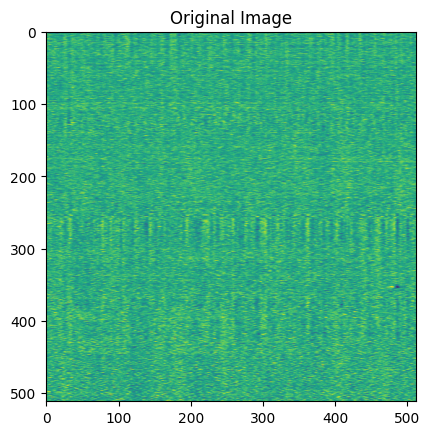

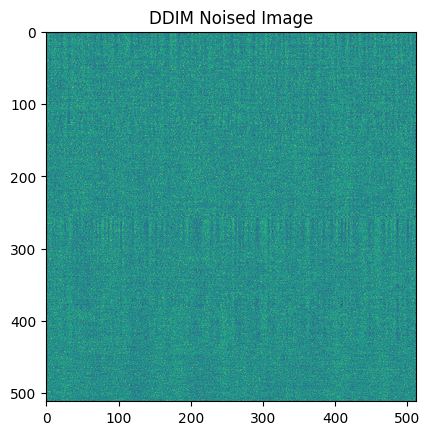

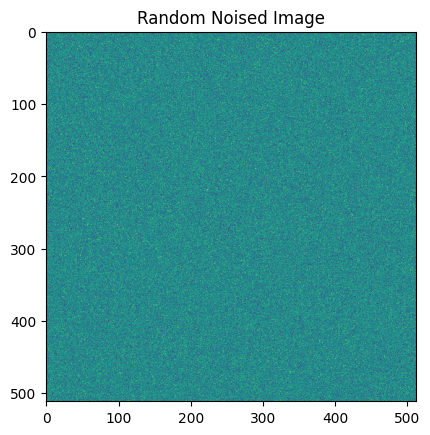

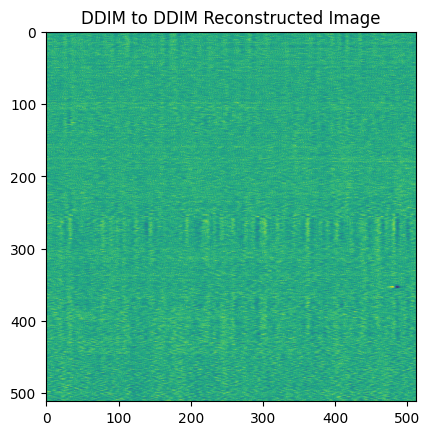

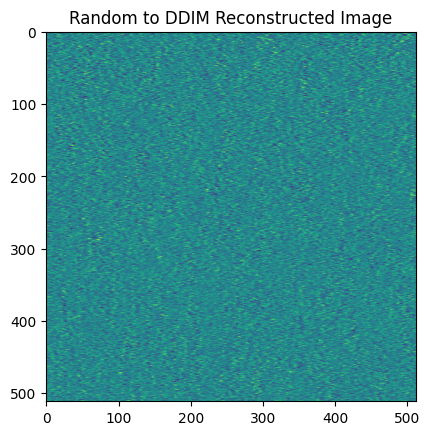

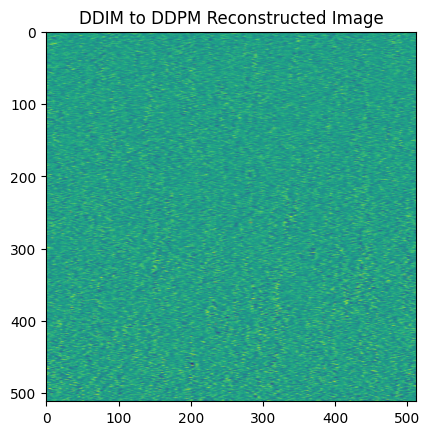

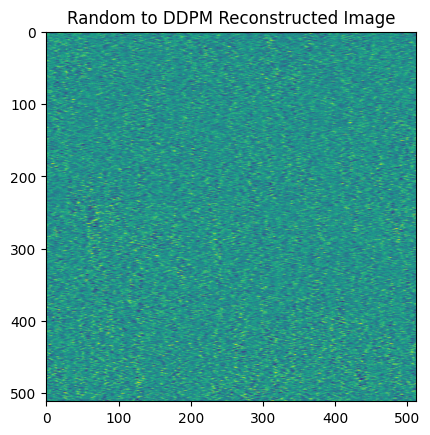

In [45]:
iidx = 2
plt.imshow(save_data[iidx]["original"][0]);
plt.title("Original Image")
plt.show()

plt.imshow(save_data[iidx]["ddim_noised-T100"][0]);
plt.title("DDIM Noised Image")
plt.show()
plt.imshow(save_data[iidx]["rand_noised-T100"][0]);
plt.title("Random Noised Image")
plt.show()

plt.imshow(save_data[iidx]["ddim2ddim-T100"][0]);
plt.title("DDIM to DDIM Reconstructed Image")
plt.show()
plt.imshow(save_data[iidx]["rand2ddim-T100"][0]);
plt.title("Random to DDIM Reconstructed Image")
plt.show()
plt.imshow(save_data[iidx]["ddim2ddpm-T100"][0]);
plt.title("DDIM to DDPM Reconstructed Image")
plt.show()
plt.imshow(save_data[iidx]["rand2ddpm-T100"][0]);
plt.title("Random to DDPM Reconstructed Image")
plt.show()

<Figure size 640x480 with 0 Axes>

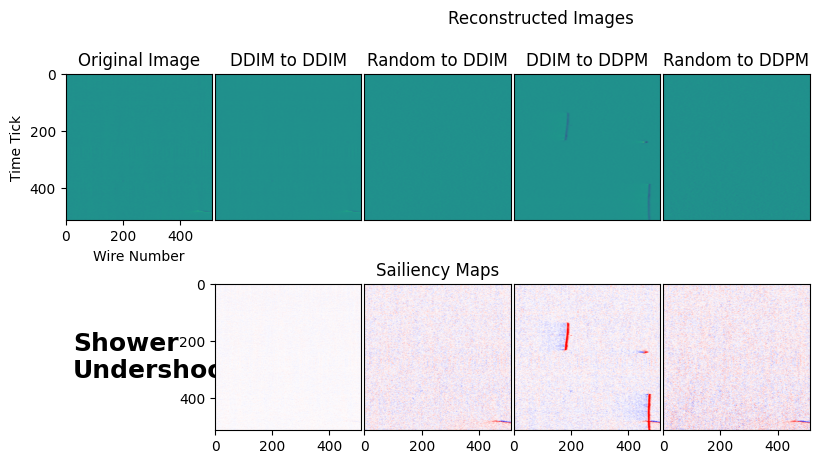

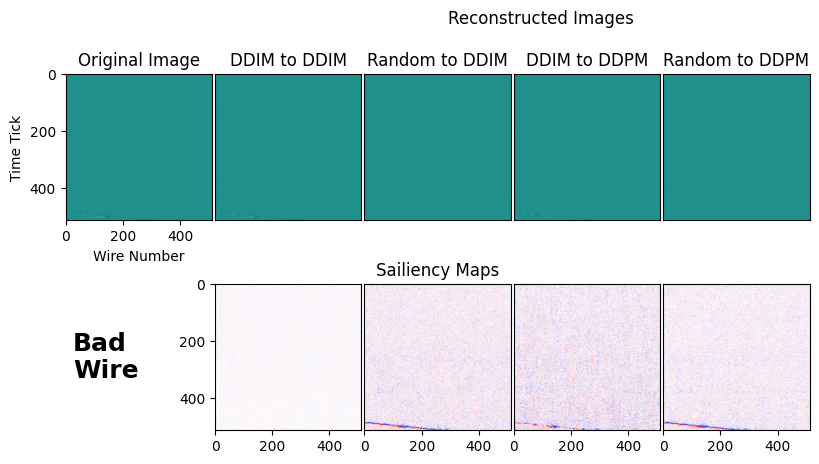

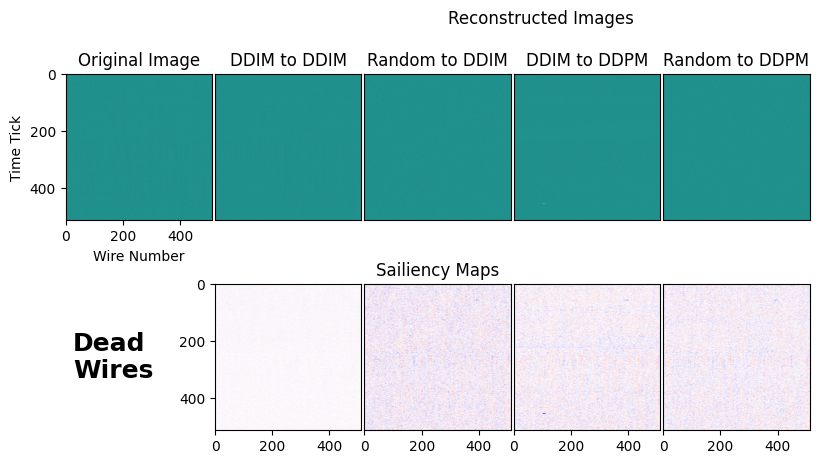

In [24]:
for ifig, title in enumerate(titles):
    plt.figure(ifig)
    fig, axs = plt.subplots(2, 5, figsize=(9.6,5))

    axs[0][0].set_title("Original Image")
    axs[0][0].imshow(np.squeeze(imgs[ifig].cpu().numpy()), vmin=-0.5, vmax=0.5)
    axs[1][0].axis('off')

    axs[1][0].text(0.05, 0.5, title.replace(" ", "\n"), horizontalalignment="left", 
                   verticalalignment="center", fontsize=18, fontweight="bold")
    
    for ireco, rname in enumerate(reco_names):
        axs[0][ireco+1].imshow(np.squeeze(recos[ireco][ifig].cpu().numpy()), vmin=-0.5, vmax=0.5)
        axs[1][ireco+1].imshow(np.squeeze((imgs[ifig] - recos[ireco][ifig]).cpu().numpy()), vmin=-0.1, vmax=0.1, cmap="bwr")
        
        axs[0][ireco+1].set_xticks([])
        axs[0][ireco+1].set_yticks([])
        
        if ireco > 0:
            axs[1][ireco+1].set_yticks([])
            
        axs[0][ireco+1].set_title(rname, fontsize=12)
            
    fig.subplots_adjust(wspace=0.02, hspace=0.2) # Make room on the right
    fig.suptitle("Reconstructed Images", x=0.62)
    axs[1][2].set_title("Sailiency Maps")
    
    axs[0][0].set_xlabel("Wire Number")
    axs[0][0].set_ylabel("Time Tick")

In [11]:
# save to dictionary

save_data = {}


# job outputs

In [21]:
import pickle

In [44]:
filename = "/scratch/7DayLifetime/munjung/ICARUS/plane0_outputs-badwire/82090893_200-bnb-nom-tpc1-plane0.npz-results.pkl"
with open(filename, "rb") as f:
    results = pickle.load(f)

print(results.keys())



dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39])


In [45]:
results[0].keys()

dict_keys(['original', 'ddim_noised-T100', 'ddim2ddim-T100', 'ddim_noised-T300', 'ddim2ddim-T300', 'ddim_noised-T500', 'ddim2ddim-T500'])

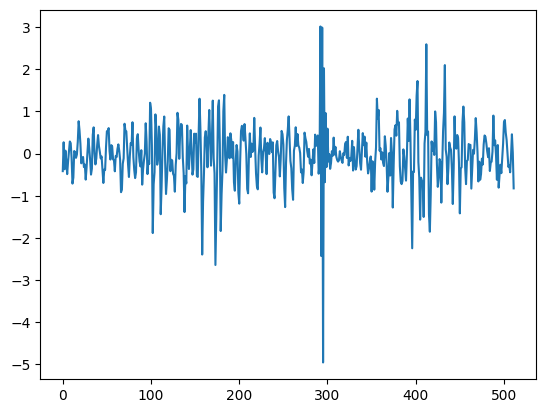

In [56]:
var = diff.sum(axis=0)
plt.plot(var)

-18.43778


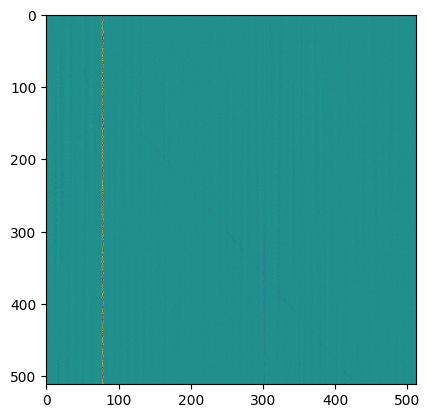

-10.494186


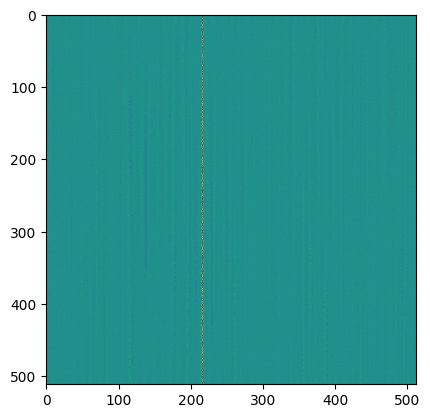

-13.482574


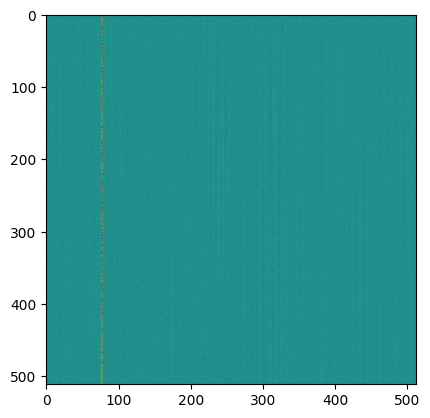

-19.395432


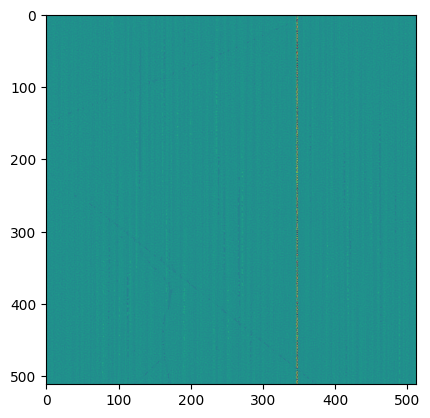

-4.428716


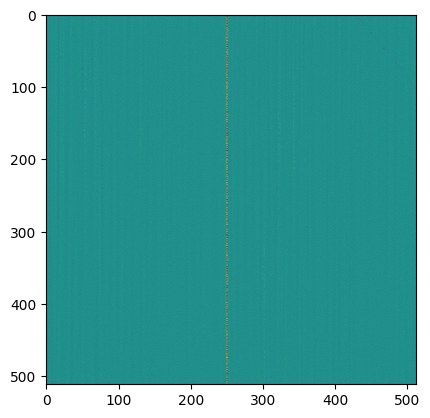

-17.066975


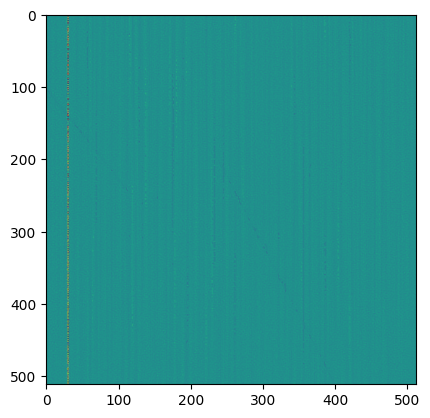

-9.211115


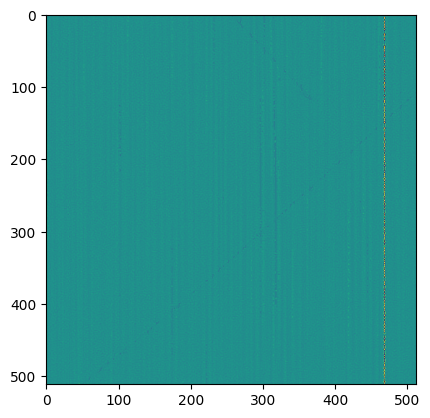

-5.612172


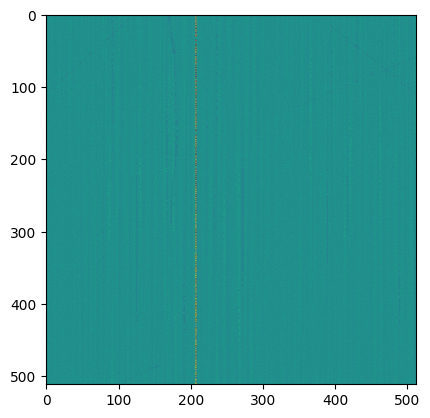

-7.22617


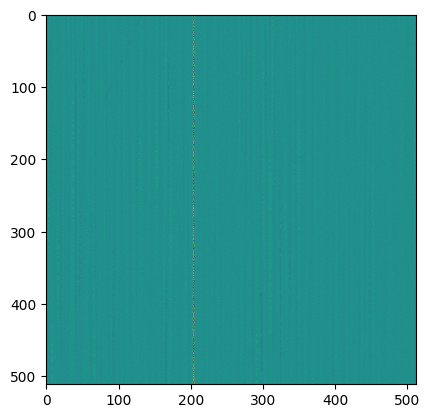

-15.147379


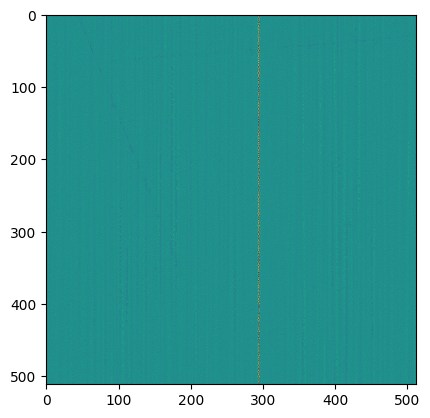

In [52]:
for iidx in range(10):
    diff = results[iidx]["ddim2ddim-T500"][0] - results[iidx]["original"][0]
    print(diff.sum())
    plt.imshow(results[iidx]["ddim2ddim-T500"][0] - results[iidx]["original"][0], vmin=-0.1, vmax=0.1)
    plt.show()

    # plt.imshow(results[iidx]["original"][0], vmin=-5, vmax=3)
    # plt.show()